## Spatial Mapping of H3 Hexagon Grid to Census Tracts

In [1]:
import pandas as pd
import geopandas as gpd
import h3
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
TRACT_COL = 'census_t_1'

df = pd.read_csv(
    "../../data/trips/trips_cleaned_V1.csv",
    usecols=['trip_id', 'pickup_census_tract', 'dropoff_census_tract']
)
tracts = gpd.read_file("../../data/Census_Tracts_Chicago.geojson").to_crs(4326)
tracts[TRACT_COL] = tracts[TRACT_COL].astype(str)

print(f"Trips:         {len(df):,}")
print(f"Census tracts: {len(tracts)}")
df.head()

Trips:         5,637,179
Census tracts: 878


,trip_id,pickup_census_tract,dropoff_census_tract
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,1.703108e+10,1.703108e+10
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,1.703176e+10,1.703106e+10
2,17365c83264f028a307ac70308d770fe03bcbcae,1.703108e+10,1.703107e+10
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,1.703122e+10,1.703107e+10
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,1.703108e+10,1.703103e+10


## Option 1: Area-Weighted Census Tract → H3 Mapping

For each census tract, finds all intersecting H3 cells and weights them by intersection area. Trips are then probabilistically assigned to a hexagon based on the area-weight distribution of their census tract.

In [13]:
def build_hex_coverage(tracts_gdf, res_level, tract_col=TRACT_COL):
    """
    For every census tract, find all H3 cells that share area with it and
    compute intersection-area weights (sum to 1 per tract).

    Returns DataFrame columns: [tract_id, h3_cell, weight]
    """
    rows = []

    for _, row in tracts_gdf.iterrows():
        tract_id = row[tract_col]
        geom = row.geometry

        # h3.geo_to_cells only handles Polygon, not MultiPolygon — iterate over parts
        parts = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
        cells = set()
        for part in parts:
            cells.update(h3.geo_to_cells(part.__geo_interface__, res_level))

        # Fallback for tracts smaller than one H3 cell
        if not cells:
            c = geom.centroid
            cells = {h3.latlng_to_cell(c.y, c.x, res_level)}

        # Expand by one ring to capture border cells that partially overlap
        candidates = set(cells)
        for cell in cells:
            candidates.update(h3.grid_disk(cell, 1))

        # Keep only cells with actual overlap; area in degrees² (ratio only)
        for cell in candidates:
            hex_poly = Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            area = geom.intersection(hex_poly).area
            if area > 0:
                rows.append({'tract_id': tract_id, 'h3_cell': cell, 'area': area})

    coverage = pd.DataFrame(rows)
    total = coverage.groupby('tract_id')['area'].transform('sum')
    coverage['weight'] = coverage['area'] / total
    return coverage[['tract_id', 'h3_cell', 'weight']]

In [14]:
resolutions = {'low': 6, 'medium': 7, 'high': 8}

coverage = {}
for res_name, res_level in resolutions.items():
    print(f"Building {res_name} resolution (level {res_level}) …", flush=True)
    coverage[res_name] = build_hex_coverage(tracts, res_level)
    print(f"  → {len(coverage[res_name]):,} tract-cell pairs")

Building low resolution (level 6) …
  → 1,172 tract-cell pairs
Building medium resolution (level 7) …
  → 1,736 tract-cell pairs
Building high resolution (level 8) …
  → 3,650 tract-cell pairs


In [15]:
from shapely.geometry import Point

# For large tracts where area-weighting misleads (e.g. an airport spanning many hexagons
# but trips only go to the terminal), pin trips to the actual activity location(s).
# Value = list of (lat, lon) tuples; multiple entries give equal-weight alternatives.
pinned_locations = {
    "ohare_terminal":     (41.9786, -87.9048),   # O'Hare terminal complex
    "big_marsh_entrance": (41.668,  -87.554),    # Big Marsh Park main entrance / parking
}

pts = gpd.GeoDataFrame(
    {"name": list(pinned_locations.keys())},
    geometry=[Point(lon, lat) for lat, lon in pinned_locations.values()],
    crs=4326,
)
joined = gpd.sjoin(pts, tracts[[TRACT_COL, "geometry"]], how="left", predicate="within")

# tract_overrides: tract_id (str) → list of (lat, lon)
tract_overrides = {
    row[TRACT_COL]: [pinned_locations[row["name"]]]
    for _, row in joined.iterrows()
    if pd.notna(row[TRACT_COL])
}

print("Pinned tract overrides:")
for tid, locs in tract_overrides.items():
    print(f"  tract {tid}  →  {locs}")

Pinned tract overrides:
  tract 17031760900  →  [(41.9786, -87.9048)]
  tract 17031510400  →  [(41.668, -87.554)]


In [16]:
rng = np.random.default_rng(42)

for res_name, res_level in resolutions.items():
    # lookup: tract_id (str) → (cells_array, weights_array)
    lookup = {
        tid: (grp['h3_cell'].values, grp['weight'].values)
        for tid, grp in coverage[res_name].groupby('tract_id')
    }

    # Patch lookup for pinned tracts: replace area-weighted distribution with
    # the exact hexagon(s) covering the actual activity location.
    for tract_id, locs in tract_overrides.items():
        cells = np.array(list({h3.latlng_to_cell(lat, lon, res_level) for lat, lon in locs}))
        lookup[tract_id] = (cells, np.ones(len(cells)) / len(cells))

    for direction in ('pickup', 'dropoff'):
        tract_col = f'{direction}_census_tract'
        h3_col    = f'{direction}_h3_{res_name}'
        result    = np.full(len(df), None, dtype=object)

        # Batch-assign all trips sharing the same census tract at once
        for tract_id, idx in df.groupby(tract_col).groups.items():
            key = str(int(tract_id))
            if key not in lookup:
                continue
            cells, weights = lookup[key]
            result[idx] = rng.choice(cells, size=len(idx), p=weights)

        df[h3_col] = result

    pickup_na  = df[f'pickup_h3_{res_name}'].isna().sum()
    dropoff_na = df[f'dropoff_h3_{res_name}'].isna().sum()
    print(f"{res_name}: pickup NAs={pickup_na:,}  dropoff NAs={dropoff_na:,}")

df.head()

low: pickup NAs=1,343,113  dropoff NAs=1,235,063
medium: pickup NAs=1,343,113  dropoff NAs=1,235,063
high: pickup NAs=1,343,113  dropoff NAs=1,235,063


,trip_id,pickup_census_tract,dropoff_census_tract,pickup_h3_low,dropoff_h3_low,pickup_h3_medium,dropoff_h3_medium,pickup_h3_high,dropoff_h3_high
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,1.703108e+10,1.703108e+10,862664c1fffffff,862664c17ffffff,872664c1effffff,872664c1effffff,882664c1edfffff,882664c1edfffff
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,1.703176e+10,1.703106e+10,862759347ffffff,862664c17ffffff,87275934effffff,872664c16ffffff,88275934edfffff,882664c163fffff
2,17365c83264f028a307ac70308d770fe03bcbcae,1.703108e+10,1.703107e+10,862664c1fffffff,862664c17ffffff,872664c1effffff,872664c13ffffff,882664c1edfffff,882664c12bfffff
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,1.703122e+10,1.703107e+10,862664ca7ffffff,862664c17ffffff,872664ca1ffffff,872664c12ffffff,882664ca17fffff,882664c13dfffff
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,1.703108e+10,1.703103e+10,862664c17ffffff,862664d8fffffff,872664c1effffff,872664d89ffffff,882664c1e5fffff,882664d891fffff


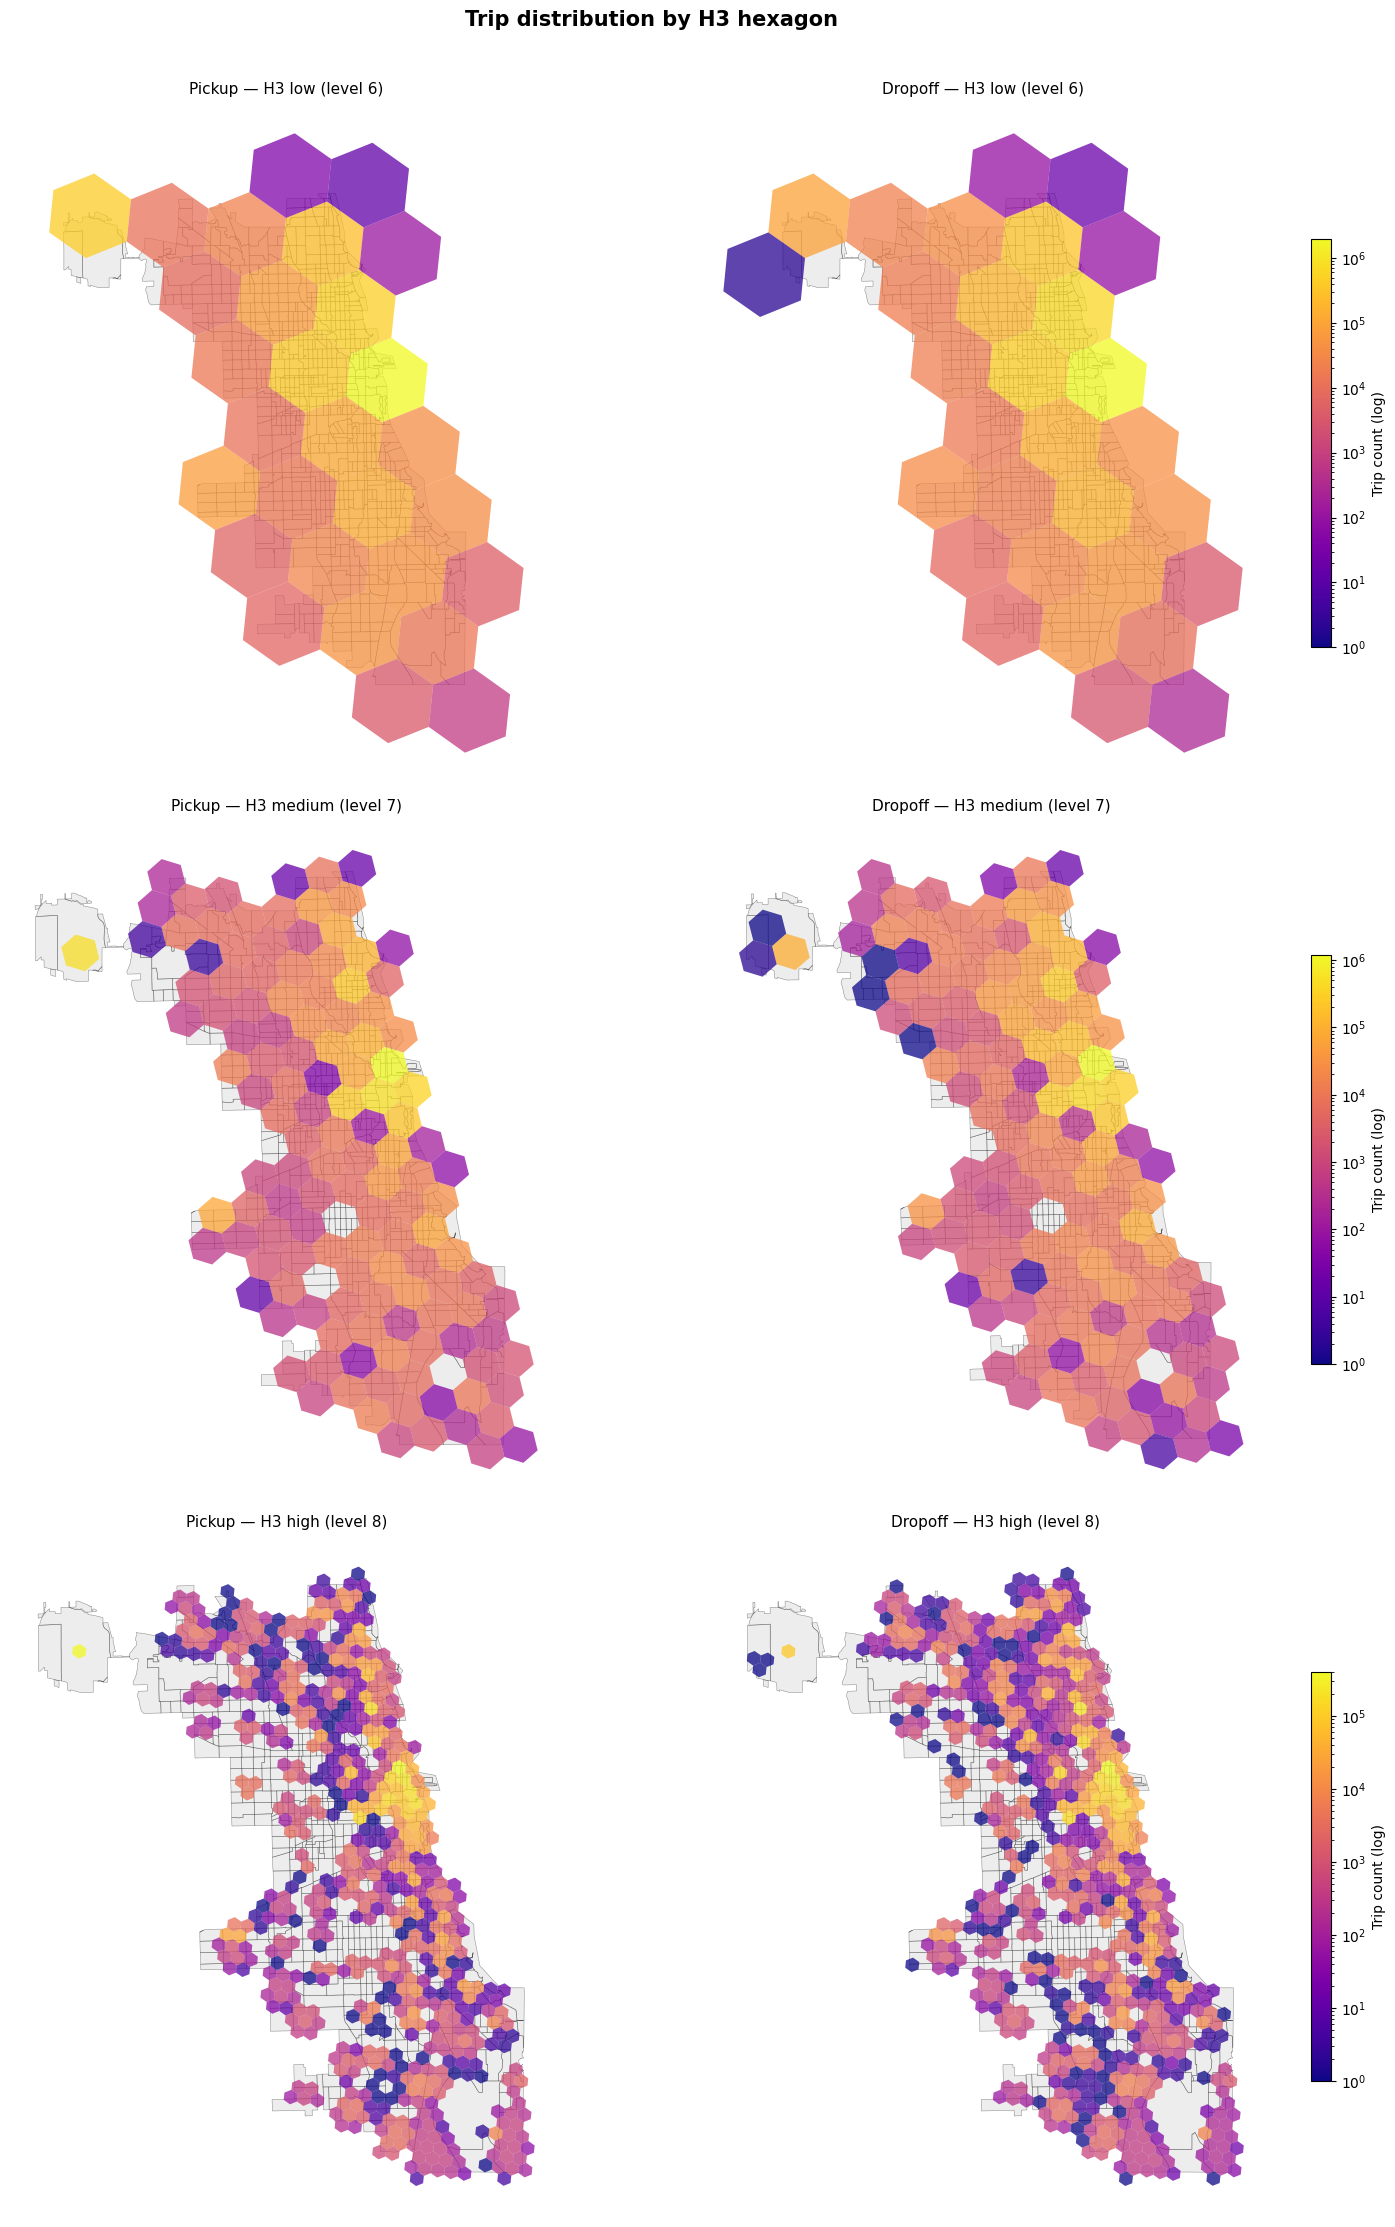

In [18]:
# H3 choropleths — one row per resolution, pickup / dropoff side by side
fig, axes = plt.subplots(3, 2, figsize=(16, 22))

for row_idx, (res_name, res_level) in enumerate(resolutions.items()):
    for col_idx, direction in enumerate(('pickup', 'dropoff')):
        ax = axes[row_idx, col_idx]

        counts = df[f'{direction}_h3_{res_name}'].value_counts().dropna()

        # Build H3 GeoDataFrame for cells that have at least one trip
        polys = [
            Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            for cell in counts.index
        ]
        hex_gdf = gpd.GeoDataFrame(
            {'count': counts.values, 'geometry': polys}, crs=4326
        )

        # Base layer: census tract outlines
        tracts.plot(ax=ax, facecolor='lightgray', edgecolor='black',
                    linewidth=0.4, alpha=0.4)

        # H3 layer coloured by trip count
        hex_gdf.plot(
            ax=ax, column='count', cmap='plasma',
            norm=LogNorm(vmin=1, vmax=counts.max()),
            legend=(col_idx == 1),
            legend_kwds={'label': 'Trip count (log)', 'shrink': 0.6},
            alpha=0.75, edgecolor='none'
        )

        ax.set_title(
            f'{direction.capitalize()} — H3 {res_name} (level {res_level})',
            fontsize=11
        )
        ax.set_axis_off()

plt.suptitle('Trip distribution by H3 hexagon', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Option 2: Direct Coordinate → H3 Mapping

Maps each trip's pickup/dropoff lat/lon coordinates directly to an H3 cell using `h3.latlng_to_cell`. Each trip gets a deterministic, exact hexagon based on its centroid coordinates.

In [9]:
df2 = pd.read_csv(
    "../../data/trips/trips_cleaned_V1.csv",
    usecols=[
        'trip_id',
        'pickup_centroid_latitude',  'pickup_centroid_longitude',
        'dropoff_centroid_latitude', 'dropoff_centroid_longitude'
    ]
)
print(f"Trips loaded: {len(df2):,}")
df2.head()

Trips loaded: 5,637,179


,trip_id,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,41.899602,-87.633308,41.899602,-87.633308
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,41.980264,-87.913625,41.944227,-87.655998
2,17365c83264f028a307ac70308d770fe03bcbcae,41.899602,-87.633308,41.922686,-87.649489
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,41.922761,-87.699155,41.922686,-87.649489
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,41.899602,-87.633308,41.965812,-87.655879


In [10]:
resolutions = {'low': 6, 'medium': 7, 'high': 8}

for res_name, res_level in resolutions.items():
    df2[f'pickup_h3_{res_name}'] = list(map(
        lambda lat, lon: h3.latlng_to_cell(lat, lon, res_level),
        df2['pickup_centroid_latitude'],
        df2['pickup_centroid_longitude']
    ))
    df2[f'dropoff_h3_{res_name}'] = list(map(
        lambda lat, lon: h3.latlng_to_cell(lat, lon, res_level),
        df2['dropoff_centroid_latitude'],
        df2['dropoff_centroid_longitude']
    ))

    pickup_na  = df2[f'pickup_h3_{res_name}'].isna().sum()
    dropoff_na = df2[f'dropoff_h3_{res_name}'].isna().sum()
    print(f"{res_name}: pickup NAs={pickup_na:,}  dropoff NAs={dropoff_na:,}")

df2.head()

low: pickup NAs=0  dropoff NAs=0
medium: pickup NAs=0  dropoff NAs=0
high: pickup NAs=0  dropoff NAs=0


,trip_id,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_h3_low,dropoff_h3_low,pickup_h3_medium,dropoff_h3_medium,pickup_h3_high,dropoff_h3_high
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,41.899602,-87.633308,41.899602,-87.633308,862664c1fffffff,862664c1fffffff,872664c1effffff,872664c1effffff,882664c1edfffff,882664c1edfffff
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,41.980264,-87.913625,41.944227,-87.655998,862759347ffffff,862664c17ffffff,872759343ffffff,872664c16ffffff,8827593433fffff,882664c163fffff
2,17365c83264f028a307ac70308d770fe03bcbcae,41.899602,-87.633308,41.922686,-87.649489,862664c1fffffff,862664c17ffffff,872664c1effffff,872664c13ffffff,882664c1edfffff,882664c107fffff
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,41.922761,-87.699155,41.922686,-87.649489,862664ca7ffffff,862664c17ffffff,872664ca1ffffff,872664c13ffffff,882664ca11fffff,882664c107fffff
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,41.899602,-87.633308,41.965812,-87.655879,862664c1fffffff,862664d8fffffff,872664c1effffff,872664d89ffffff,882664c1edfffff,882664d897fffff


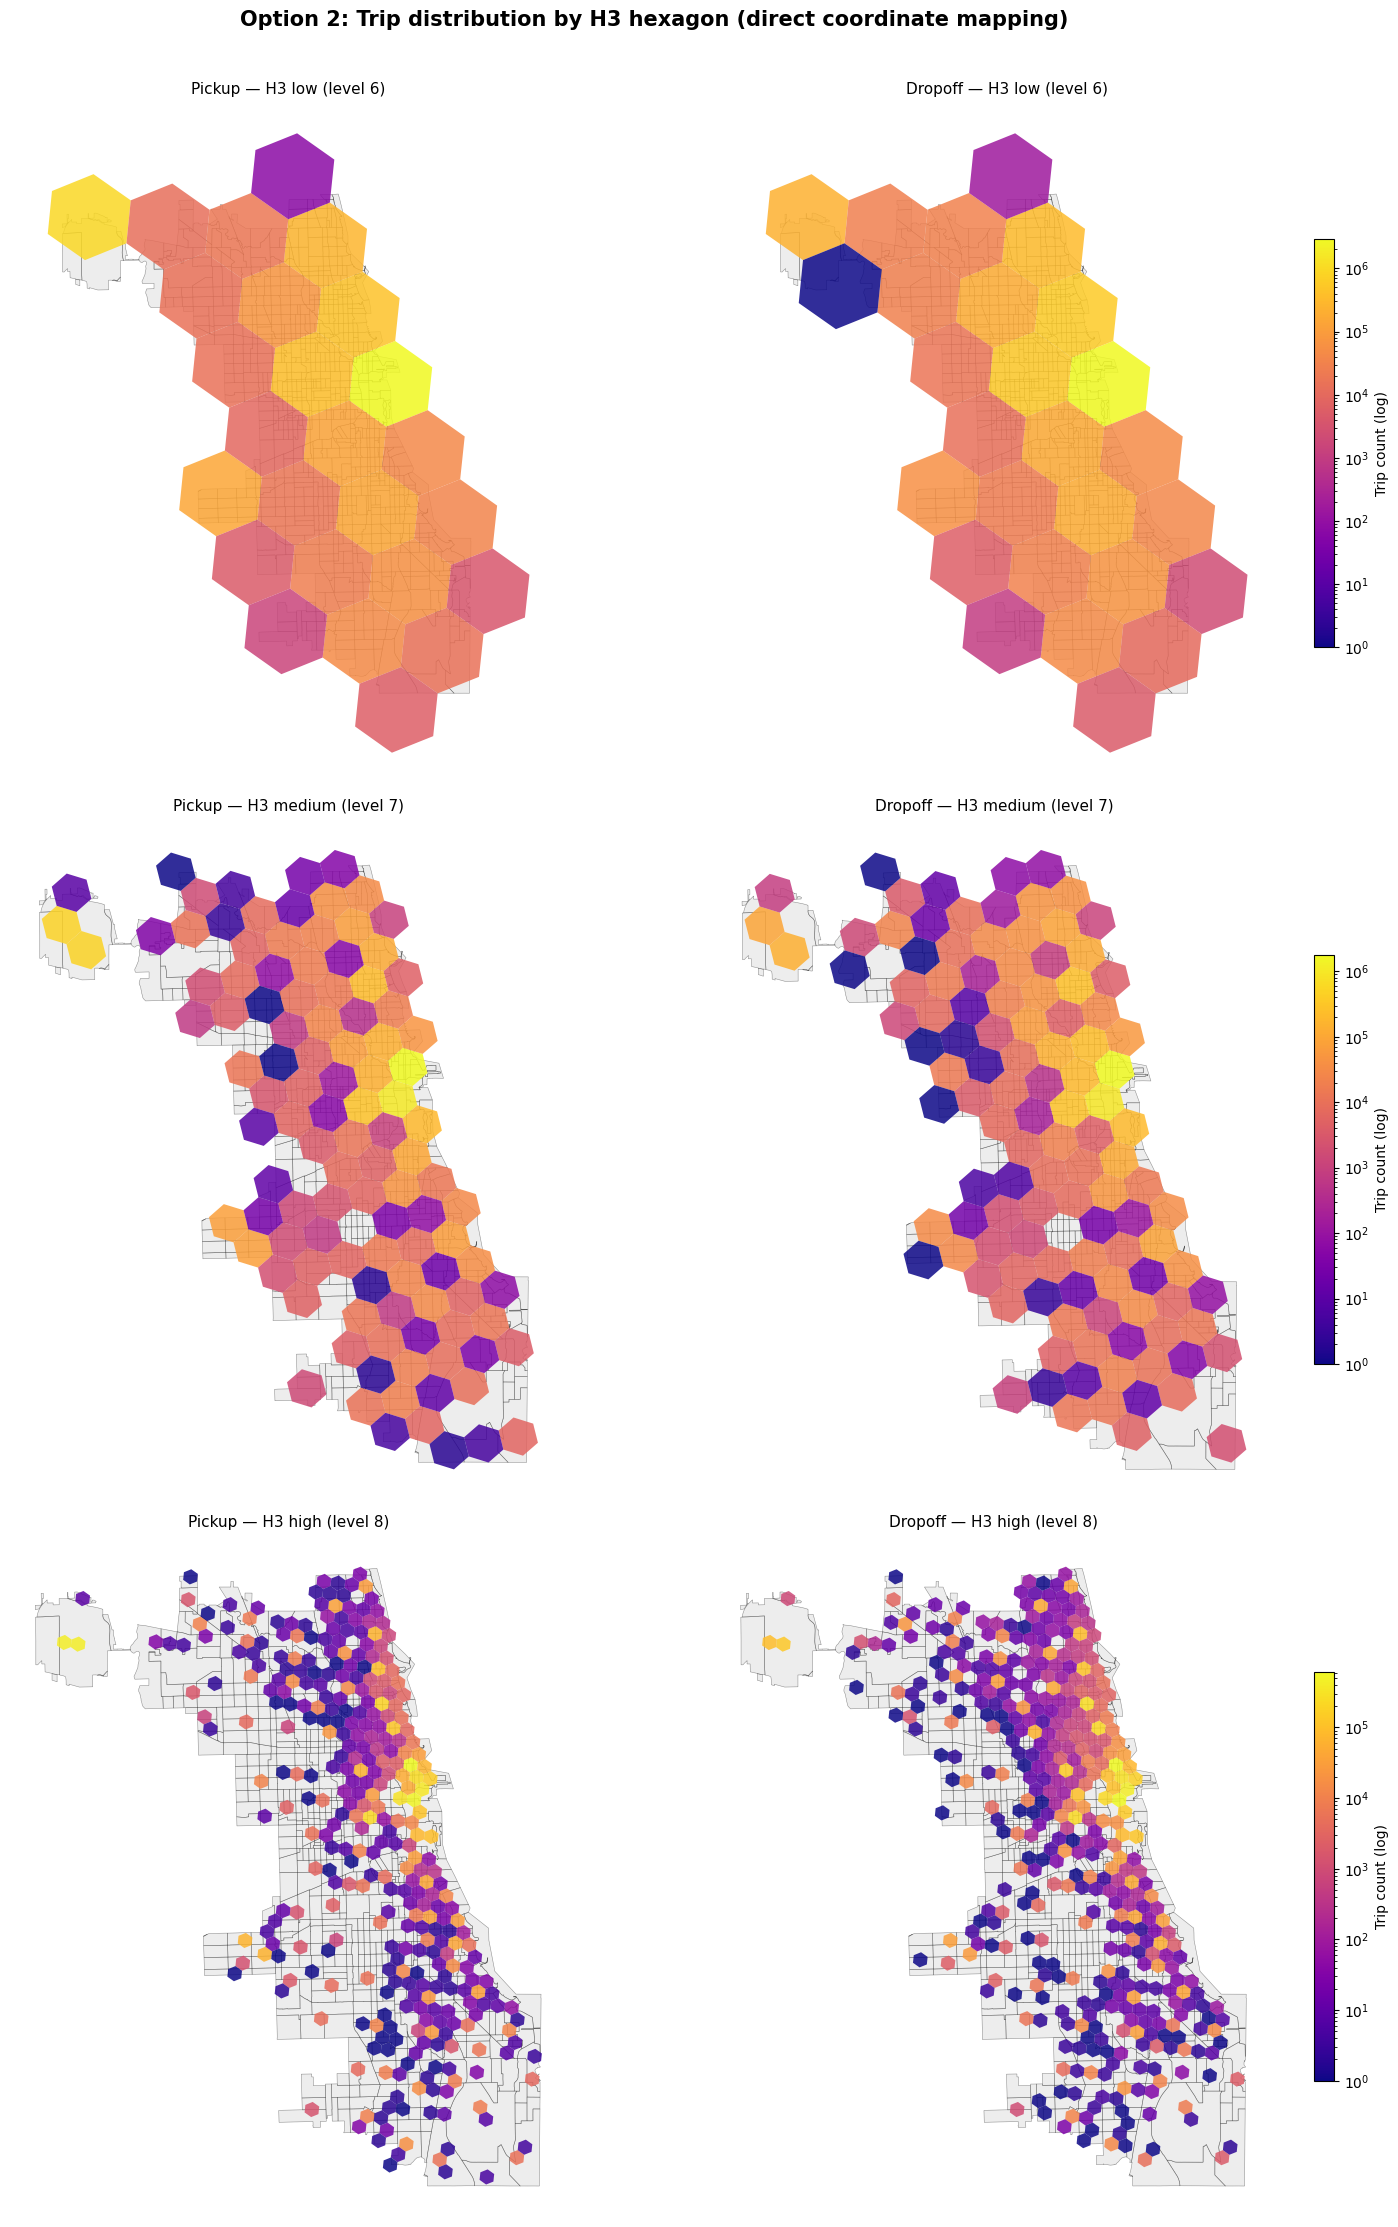

In [11]:
# H3 choropleths — one row per resolution, pickup / dropoff side by side
fig, axes = plt.subplots(3, 2, figsize=(16, 22))

for row_idx, (res_name, res_level) in enumerate(resolutions.items()):
    for col_idx, direction in enumerate(('pickup', 'dropoff')):
        ax = axes[row_idx, col_idx]

        counts = df2[f'{direction}_h3_{res_name}'].value_counts().dropna()

        polys = [
            Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            for cell in counts.index
        ]
        hex_gdf = gpd.GeoDataFrame(
            {'count': counts.values, 'geometry': polys}, crs=4326
        )

        tracts.plot(ax=ax, facecolor='lightgray', edgecolor='black',
                    linewidth=0.4, alpha=0.4)

        hex_gdf.plot(
            ax=ax, column='count', cmap='plasma',
            norm=LogNorm(vmin=1, vmax=counts.max()),
            legend=(col_idx == 1),
            legend_kwds={'label': 'Trip count (log)', 'shrink': 0.6},
            alpha=0.85, edgecolor='none'
        )

        ax.set_title(
            f'{direction.capitalize()} — H3 {res_name} (level {res_level})',
            fontsize=11
        )
        ax.set_axis_off()

plt.suptitle('Option 2: Trip distribution by H3 hexagon (direct coordinate mapping)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Raw Data — Census Tract Choropleth (after `fill_tract`)

In [ ]:
# Census tract choropleth (pickup + dropoff)
pickup_ct  = df['pickup_census_tract'].value_counts().rename('count')
dropoff_ct = df['dropoff_census_tract'].value_counts().rename('count')

# Tract IDs are float64 in the CSV ("17031081000.0") — convert to clean int strings
pickup_ct.index  = pickup_ct.index.map(lambda x: str(int(x)))
dropoff_ct.index = dropoff_ct.index.map(lambda x: str(int(x)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, counts, title in zip(
    axes,
    [pickup_ct, dropoff_ct],
    ['Pickup trips per census tract', 'Dropoff trips per census tract']
):
    plot_gdf = tracts[[TRACT_COL, 'geometry']].copy()
    plot_gdf['count'] = plot_gdf[TRACT_COL].map(counts).fillna(0).astype(int)

    plot_gdf.plot(
        ax=ax, column='count', cmap='YlOrRd',
        norm=LogNorm(vmin=max(1, plot_gdf['count'][plot_gdf['count'] > 0].min()),
                     vmax=plot_gdf['count'].max()),
        legend=True,
        legend_kwds={'label': 'Trip count (log)', 'shrink': 0.7},
        edgecolor='black', linewidth=0.3
    )
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

plt.suptitle('Trip distribution by census tract', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Raw rows: 6,825,838
After fill_tract — remaining NaN:  pickup=182,461  dropoff=545,974

Chicago tracts with ≥1 pickup:  376 / 878
Chicago tracts with ≥1 dropoff: 417 / 878


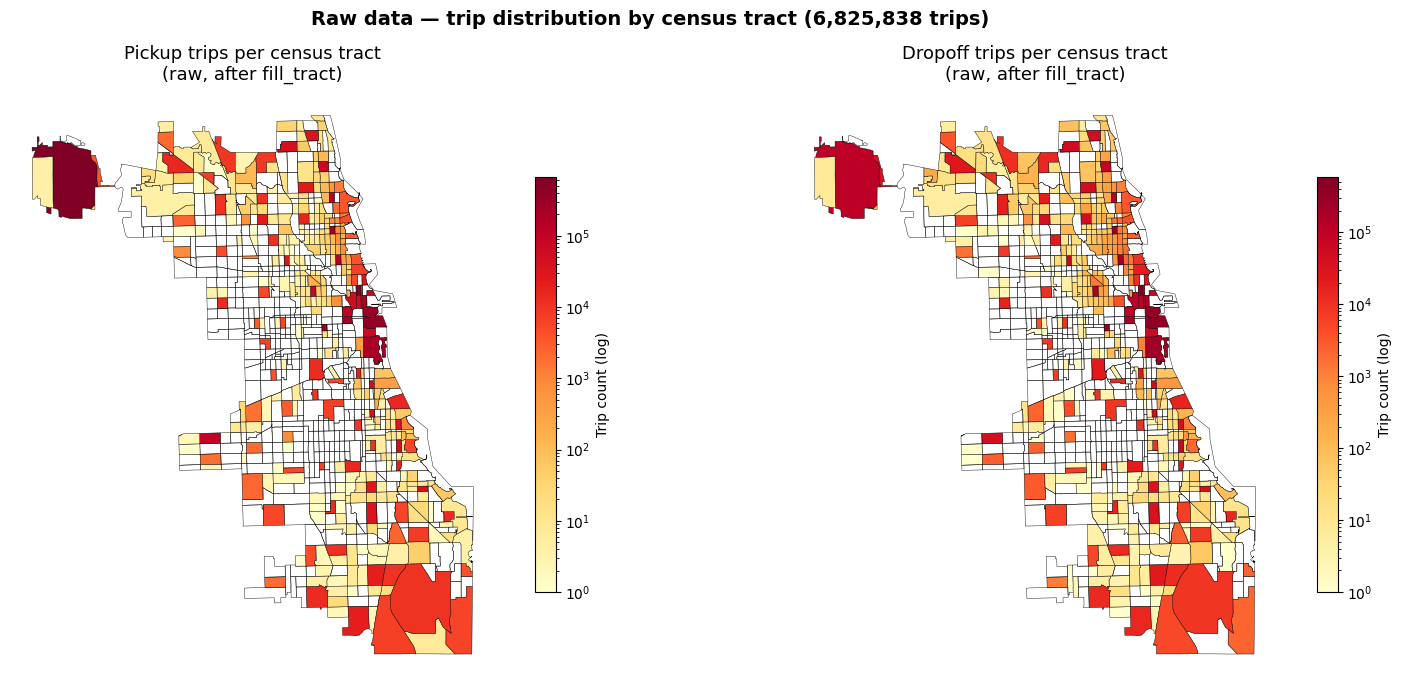

In [12]:
# Load only the columns needed for the spatial imputation
raw = pd.read_csv(
    "../../data/trips/CHICAGO_TAXI_TRIPS_2025.csv",
    usecols=['pickup_census_tract', 'dropoff_census_tract',
             'pickup_centroid_latitude',  'pickup_centroid_longitude',
             'dropoff_centroid_latitude', 'dropoff_centroid_longitude']
)
# Cast to object so string values from the spatial join can be assigned into float64 columns
raw['pickup_census_tract']  = raw['pickup_census_tract'].astype(object)
raw['dropoff_census_tract'] = raw['dropoff_census_tract'].astype(object)
print(f"Raw rows: {len(raw):,}")

# --- fill_tract: spatial-join coords → census tract for rows missing a tract ---
# Optimised: only join the ~585 unique coordinate pairs, then map back via merge
def fill_tract_col(df, lat_col, lon_col, tract_col):
    mask = df[tract_col].isna() & df[lat_col].notna()
    if not mask.any():
        return

    # Unique coords only (avoids a multi-million-row spatial join)
    unique_coords = (
        df.loc[mask, [lat_col, lon_col]]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    pts = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(unique_coords[lon_col], unique_coords[lat_col]),
        crs=4326
    )
    joined = gpd.sjoin(pts, tracts[[TRACT_COL, 'geometry']],
                       how='left', predicate='within')
    unique_coords[TRACT_COL] = joined[TRACT_COL].values

    # Broadcast result back to all matching rows via a merge
    filled = df.loc[mask, [lat_col, lon_col]].merge(
        unique_coords[[lat_col, lon_col, TRACT_COL]],
        on=[lat_col, lon_col], how='left'
    )
    df.loc[mask, tract_col] = filled[TRACT_COL].astype(object).values

fill_tract_col(raw, 'pickup_centroid_latitude',  'pickup_centroid_longitude',  'pickup_census_tract')
fill_tract_col(raw, 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'dropoff_census_tract')

print(f"After fill_tract — remaining NaN:  pickup={raw['pickup_census_tract'].isna().sum():,}  "
      f"dropoff={raw['dropoff_census_tract'].isna().sum():,}")

# Normalise IDs: raw floats ("17031081000.0") and GeoJSON strings ("17031081000")
def to_str(x):
    try:
        return str(int(float(x)))
    except:
        return None

pickup_ct_raw  = raw['pickup_census_tract'].map(to_str).value_counts()
dropoff_ct_raw = raw['dropoff_census_tract'].map(to_str).value_counts()

# Filter to Chicago tracts only
chicago_ids = set(tracts[TRACT_COL])
pickup_ct_raw  = pickup_ct_raw[pickup_ct_raw.index.isin(chicago_ids)]
dropoff_ct_raw = dropoff_ct_raw[dropoff_ct_raw.index.isin(chicago_ids)]

print(f"\nChicago tracts with ≥1 pickup:  {len(pickup_ct_raw)} / {len(chicago_ids)}")
print(f"Chicago tracts with ≥1 dropoff: {len(dropoff_ct_raw)} / {len(chicago_ids)}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, counts, title in zip(
    axes,
    [pickup_ct_raw, dropoff_ct_raw],
    ['Pickup trips per census tract\n(raw, after fill_tract)',
     'Dropoff trips per census tract\n(raw, after fill_tract)']
):
    plot_gdf = tracts[[TRACT_COL, 'geometry']].copy()
    plot_gdf['count'] = plot_gdf[TRACT_COL].map(counts).fillna(0).astype(int)

    plot_gdf.plot(
        ax=ax, column='count', cmap='YlOrRd',
        norm=LogNorm(vmin=max(1, plot_gdf['count'][plot_gdf['count'] > 0].min()),
                     vmax=plot_gdf['count'].max()),
        legend=True,
        legend_kwds={'label': 'Trip count (log)', 'shrink': 0.7},
        edgecolor='black', linewidth=0.3
    )
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

plt.suptitle('Raw data — trip distribution by census tract (6,825,838 trips)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()